In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Загрузка данных
df = pd.read_csv('heart.csv')
#Первые 5 строк
print("Первые 5 строк датасета:")
display(df.head())
#Информация о датасете
print("\nИнформация о датасете:")
df.info()
#Проверка пропусков
print("\nКоличество пропусков:")
print(df.isnull().sum())

Первые 5 строк датасета:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Количество пропусков:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal

количество здоровых пациентов: 138
количество больных пациентов: 165


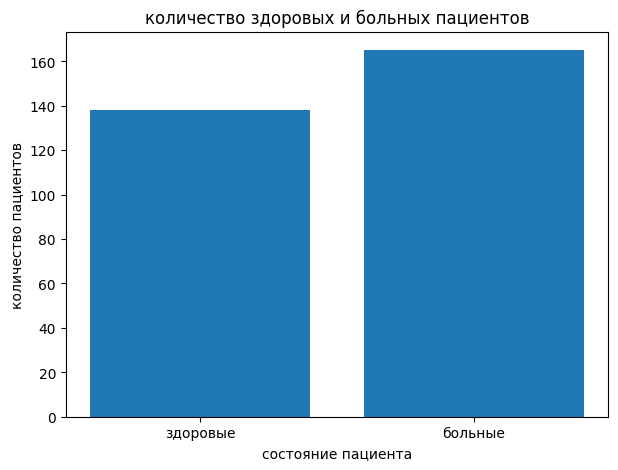

In [9]:
#Задача 2. Количество здоровых и больных пациентов
healthy = (df['target'] == 0).sum()
sick = (df['target'] == 1).sum()
print("количество здоровых пациентов:", healthy)
print("количество больных пациентов:", sick)
plt.figure(figsize=(7, 5))
plt.bar( ['здоровые', 'больные'], [healthy, sick] )
plt.title('количество здоровых и больных пациентов')
plt.xlabel('состояние пациента')
plt.ylabel('количество пациентов')
plt.show()

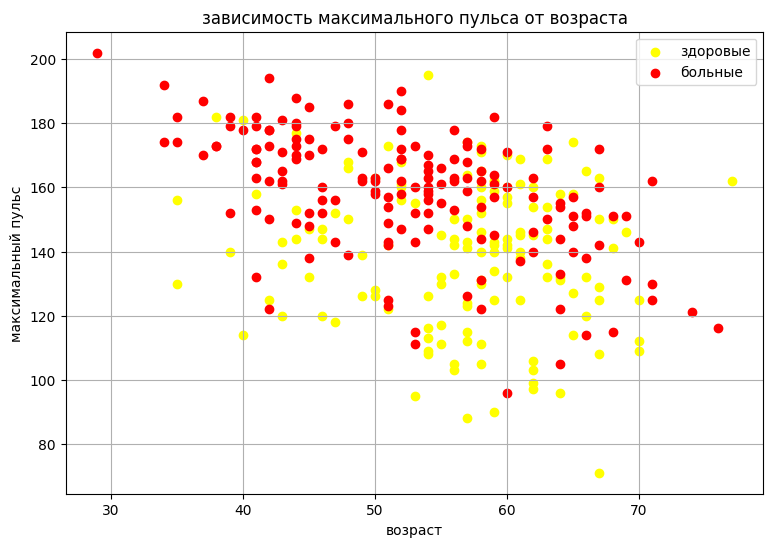

In [16]:
#Задача 3. Зависимость максимального пульса от возраста
plt.figure(figsize=(9, 6))
#Здоровые пациенты
plt.scatter( df[df['target'] == 0]['age'], df[df['target'] == 0]['thalach'],color='yellow', label='здоровые' )
#Больные пациенты
plt.scatter( df[df['target'] == 1]['age'], df[df['target'] == 1]['thalach'],color='red', label='больные' )
plt.title('зависимость максимального пульса от возраста')
plt.xlabel('возраст')
plt.ylabel('максимальный пульс')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#Задача 4. Преобразование признака sex
df['sex_category'] = df['sex'].map({ 0: 'female', 1: 'male' })
print("Преобразованный признак sex:")
display(df[['sex', 'sex_category']].head())

df = pd.get_dummies( df, columns=['sex_category'], prefix='sex' )
print("После One-Hot Encoding:")
display(df[['sex', 'sex_female', 'sex_male']].head())

Преобразованный признак sex:


,sex,sex_category
0,1,male
1,1,male
2,0,female
3,1,male
4,0,female


После One-Hot Encoding:


,sex,sex_female,sex_male
0,1,False,True
1,1,False,True
2,0,True,False
3,1,False,True
4,0,True,False


средний уровень холестерина у здоровых пациентов: 251.09
средний уровень холестерина у больных пациентов: 242.23


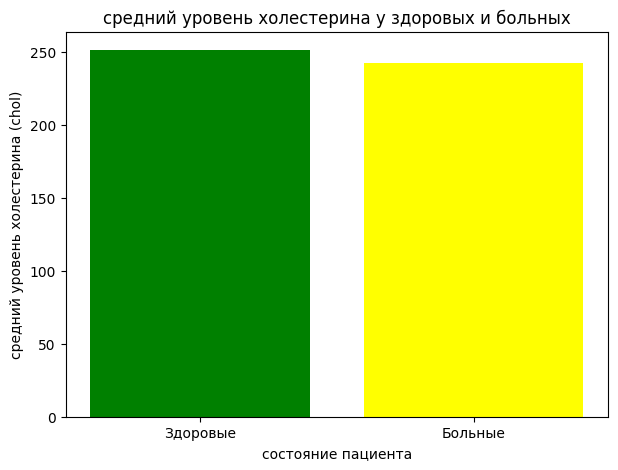

In [22]:
#Задача 5. Средний уровень холестерина
healthy_chol = df[df['target'] == 0]['chol'].mean()
sick_chol = df[df['target'] == 1]['chol'].mean()
print("средний уровень холестерина у здоровых пациентов:", round(healthy_chol, 2))
print("средний уровень холестерина у больных пациентов:", round(sick_chol, 2))
plt.figure(figsize=(7, 5))

plt.bar(
    ['Здоровые', 'Больные'],
    [healthy_chol, sick_chol],
    color=['green','yellow']
)

plt.title('средний уровень холестерина у здоровых и больных')
plt.xlabel('состояние пациента')
plt.ylabel('средний уровень холестерина (chol)')

plt.show()

In [27]:
#Задача 6. Нормализация признаков
#Нормализация age
df['age_normalized'] = ( (df['age'] - df['age'].min()) / (df['age'].max() - df['age'].min()) )
#Нормализация trestbps
df['trestbps_normalized'] = ( (df['trestbps'] - df['trestbps'].min()) / (df['trestbps'].max() - df['trestbps'].min()) )
#Нормализация chol
df['chol_normalized'] = ( (df['chol'] - df['chol'].min()) / (df['chol'].max() - df['chol'].min()) )
#Нормализация thalach
df['thalach_normalized'] = ( (df['thalach'] - df['thalach'].min()) / (df['thalach'].max() - df['thalach'].min()) )
print("Нормализация выполнена.")
#Вывод результатов
display( df[ [ 'age', 'age_normalized', 'trestbps', 'trestbps_normalized', 'chol', 'chol_normalized', 'thalach', 'thalach_normalized' ] ].head() )


Нормализация выполнена.


,age,age_normalized,trestbps,trestbps_normalized,chol,chol_normalized,thalach,thalach_normalized
0,63,0.708333,145,0.481132,233,0.244292,150,0.603053
1,37,0.166667,130,0.339623,250,0.283105,187,0.885496
2,41,0.250000,130,0.339623,204,0.178082,172,0.770992
3,56,0.562500,120,0.245283,236,0.251142,178,0.816794
4,57,0.583333,120,0.245283,354,0.520548,163,0.702290
